# 01. 데이터 확인 — StoveLens AI (SalaryCast_AI)

KBO FA 선수의 연평균 계약금을 예측하기 위해 모은 원천 데이터를 점검한다.

확인할 것
1. 네이버 스포츠에서 받은 시즌 기록이 **연도별로 빠짐없이** 들어왔는가
2. 정제한 시즌 스탯에 결측이 어디에 있는가
3. 정답이 될 FA 계약 데이터가 몇 건이고 어떤 분포인가

> 이 노트북은 데이터를 **읽기만** 한다. 수집은 `scripts/crawl_naver_v2.py`,
> 정제는 `scripts/build_season_stats_v3.py`가 한다.

## 0. 환경 설정

In [1]:
import sys, warnings
from pathlib import Path

warnings.filterwarnings("ignore")

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

DATA = ROOT / "data"
CHARTS = ROOT / "output" / "charts" / "notebook"
CHARTS.mkdir(parents=True, exist_ok=True)

# 순서 주의: seaborn의 set_style이 font.family를 sans-serif로 되돌린다.
# 폰트를 먼저 잡고 스타일을 나중에 걸면 한글이 전부 네모로 깨진다.
sns.set_style("whitegrid")

try:
    import koreanize_matplotlib  # noqa: F401
except ImportError:
    from matplotlib import font_manager
    installed = {f.name for f in font_manager.fontManager.ttflist}
    for candidate in ("NanumGothic", "AppleGothic", "Malgun Gothic", "Noto Sans CJK KR"):
        if candidate in installed:
            plt.rcParams["font.family"] = candidate
            plt.rcParams["font.sans-serif"] = [candidate]
            break
    else:
        print("경고: 한글 폰트를 못 찾았다. 라벨이 네모로 나올 수 있다.")

plt.rcParams["axes.unicode_minus"] = False
plt.rcParams["figure.dpi"] = 110

print("루트:", ROOT)
print("폰트:", plt.rcParams["font.family"])

루트: /Users/tina/Project/SalaryCast_AI
폰트: ['NanumGothic']


## 1. 원천 데이터 로드

`_raw_all`은 처음 수집한 것, `_raw_v2`는 다시 수집한 것이다.
두 파일을 같이 두는 이유는 다음 절에서 비교하기 위해서다.

이 비교는 2013~2026 구간으로 한다. 지금 쓰는 시즌 스탯은 나중에 2010년까지
더 넓혀 받은 `_2010_2026_v4`이고, 아래에서 로드하는 것도 그쪽이다.

In [2]:
raw_old = pd.read_csv(DATA / "naver_hitter_2013_2026_raw_all.csv")
raw_new = pd.read_csv(DATA / "naver_hitter_2013_2026_raw_v2.csv")
seasons_h = pd.read_csv(DATA / "hitter_season_stats_2010_2026_v4.csv")
seasons_p = pd.read_csv(DATA / "pitcher_season_stats_2010_2026_v4.csv")
fa = pd.read_csv(DATA / "fa_contracts_v7.csv")

for label, frame in [("타자 원본(구)", raw_old), ("타자 원본(신)", raw_new),
                     ("타자 시즌스탯 v4", seasons_h), ("투수 시즌스탯 v4", seasons_p),
                     ("FA 계약 v7", fa)]:
    print(f"{label:16s} {frame.shape[0]:5d}행 {frame.shape[1]:3d}컬럼")

타자 원본(구)          2061행  50컬럼
타자 원본(신)          5003행  50컬럼
타자 시즌스탯 v4        5772행  29컬럼
투수 시즌스탯 v4        4202행  32컬럼
FA 계약 v7           210행  11컬럼


## 2. 연도별 수집 인원 — 처음 수집은 70%가 비어 있었다

처음 수집은 정렬 기준별 상위 N명만 가져오는 구조에 `pageSize=100`이 걸려 있었다.
부상이나 백업으로 출전이 적은 선수는 **어느 정렬 기준에서도 상위권에 못 들어**
통째로 빠졌다. 홍창기의 2025 시즌이 없어서 발견했다 (TROUBLESHOOTING TS-001).

,기존 수집,재수집,누락률
year,,,
2019,119,352,0.662
2020,107,370,0.711
2021,109,389,0.720
2022,124,355,0.651
2023,111,366,0.697
2024,105,386,0.728
2025,120,398,0.698
2026,107,332,0.678


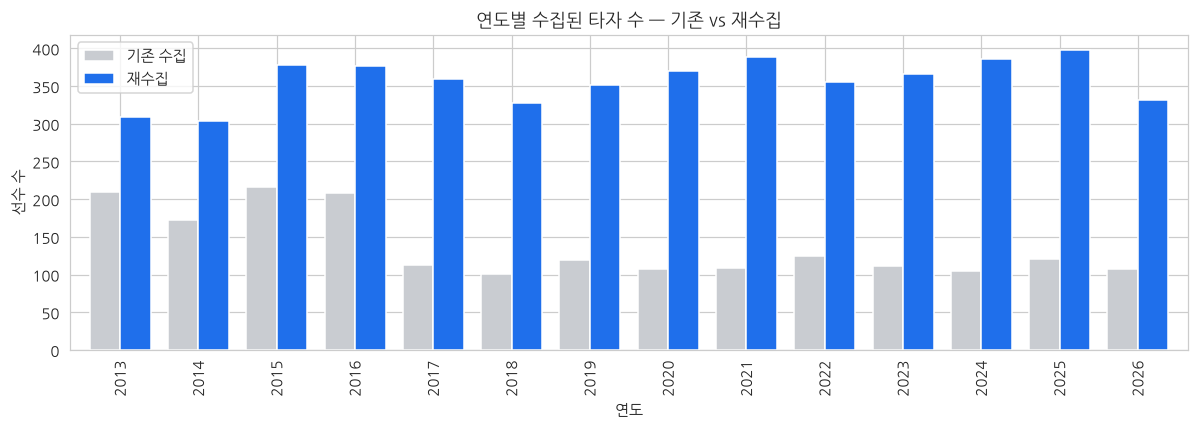

재수집으로 늘어난 타자 시즌 기록: 2061 -> 5003행


In [3]:
old_by_year = raw_old.groupby("year")["playerId"].nunique()
new_by_year = raw_new.groupby("year")["playerId"].nunique()
compare = pd.DataFrame({"기존 수집": old_by_year, "재수집": new_by_year}).fillna(0).astype(int)
compare["누락률"] = (1 - compare["기존 수집"] / compare["재수집"]).round(3)
display(compare.tail(8))

ax = compare[["기존 수집", "재수집"]].plot(
    kind="bar", figsize=(11, 4), color=["#c9ccd1", "#1f6feb"], width=0.78)
ax.set_title("연도별 수집된 타자 수 — 기존 vs 재수집")
ax.set_xlabel("연도"); ax.set_ylabel("선수 수")
ax.legend(title=None)
plt.tight_layout()
plt.savefig(CHARTS / "01_collection_coverage.png", bbox_inches="tight")
plt.show()

print(f"재수집으로 늘어난 타자 시즌 기록: {len(raw_old)} -> {len(raw_new)}행")

## 3. 결측 확인

정제된 시즌 스탯에서 값이 빈 컬럼을 본다.
비율 스탯(`babip`, `wrc_plus` 등)은 타석이 아주 적은 시즌에 계산이 안 돼 비는 경우가 있다.

[타자 시즌스탯] 결측 있는 컬럼 2개 / 전체 29개
[투수 시즌스탯] 결측 있는 컬럼 2개 / 전체 32개


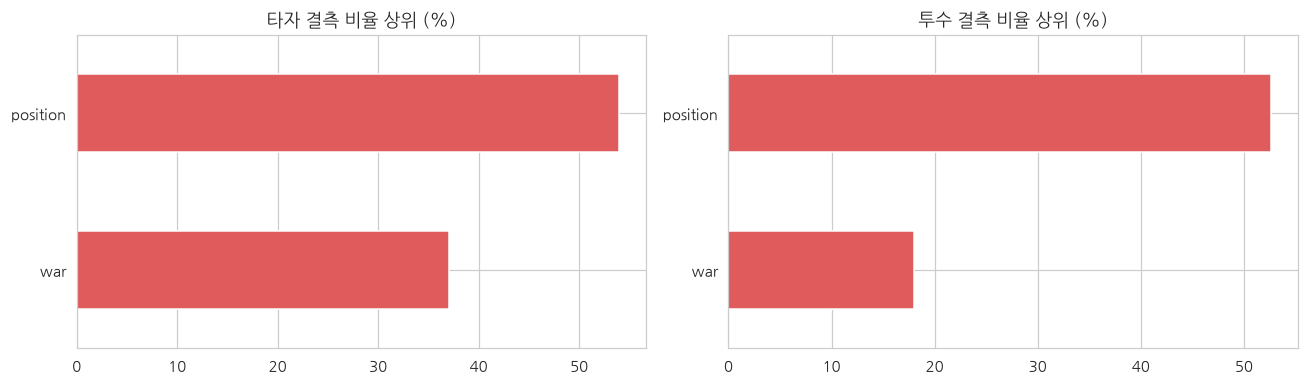

In [4]:
def missing_report(frame, label):
    ratio = (frame.isna().mean() * 100).sort_values(ascending=False)
    ratio = ratio[ratio > 0]
    print(f"[{label}] 결측 있는 컬럼 {len(ratio)}개 / 전체 {frame.shape[1]}개")
    return ratio

miss_h = missing_report(seasons_h, "타자 시즌스탯")
miss_p = missing_report(seasons_p, "투수 시즌스탯")

fig, axes = plt.subplots(1, 2, figsize=(12, 3.6))
for ax, ratio, title in [(axes[0], miss_h, "타자"), (axes[1], miss_p, "투수")]:
    if len(ratio):
        ratio.head(10).plot(kind="barh", ax=ax, color="#e05c5c")
        ax.invert_yaxis()
    else:
        ax.text(0.5, 0.5, "결측 없음", ha="center", va="center")
    ax.set_title(f"{title} 결측 비율 상위 (%)")
plt.tight_layout()
plt.savefig(CHARTS / "01_missing.png", bbox_inches="tight")
plt.show()

## 4. 정답(타깃) 데이터 — FA 계약 210건

`annual_avg_salary`가 예측 타깃이다. 단위는 **억 원**이고,
총액이 아니라 계약 기간으로 나눈 연평균이다.

In [5]:
print(f"FA 계약 {len(fa)}건 / {fa.fa_year.min()}~{fa.fa_year.max()}년")
# position은 코드다 — P 투수, C 포수, 1B/2B/3B/SS 내야, OF 외야, IF 내야 유틸
print(f"타자 {(fa.position != 'P').sum()}건 · 투수 {(fa.position == 'P').sum()}건")
display(fa.annual_avg_salary.describe().round(2).to_frame("연평균 계약금(억)"))
display(fa.nlargest(5, "annual_avg_salary")[
    ["player_name", "fa_year", "position", "contract_years",
     "total_contract_amount", "annual_avg_salary"]])

FA 계약 210건 / 2014~2026년
타자 137건 · 투수 73건


,연평균 계약금(억)
count,210.00
mean,9.99
std,7.04
min,0.55
25%,4.25
50%,8.59
75%,13.88
max,37.50


,player_name,fa_year,position,contract_years,total_contract_amount,annual_avg_salary
56,이대호,2017,1B,4,150.0,37.50
89,양의지,2019,C,4,125.0,31.25
70,김현수,2018,OF,4,115.0,28.75
136,김재환,2022,OF,4,115.0,28.75
182,최정,2025,3B,4,110.0,27.50


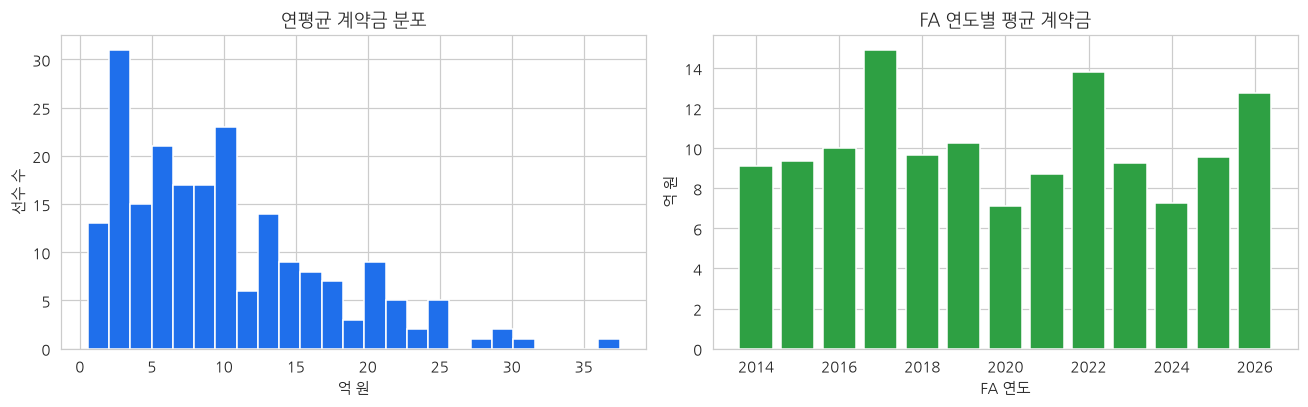

왜도(skew) 1.03 — 오른쪽으로 길게 늘어진 분포다.
소수의 대형 계약이 평균을 끌어올린다. 03에서 로그 변환을 검토한다.


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))

axes[0].hist(fa.annual_avg_salary, bins=25, color="#1f6feb", edgecolor="white")
axes[0].set_title("연평균 계약금 분포")
axes[0].set_xlabel("억 원"); axes[0].set_ylabel("선수 수")

by_year = fa.groupby("fa_year")["annual_avg_salary"].agg(["mean", "count"])
axes[1].bar(by_year.index, by_year["mean"], color="#2ea043")
axes[1].set_title("FA 연도별 평균 계약금")
axes[1].set_xlabel("FA 연도"); axes[1].set_ylabel("억 원")

plt.tight_layout()
plt.savefig(CHARTS / "01_target_distribution.png", bbox_inches="tight")
plt.show()

print(f"왜도(skew) {fa.annual_avg_salary.skew():.2f} — 오른쪽으로 길게 늘어진 분포다.")
print("소수의 대형 계약이 평균을 끌어올린다. 03에서 로그 변환을 검토한다.")

## 정리

- 처음 수집은 **연도당 선수의 상당수가 빠져 있었다.** 재수집으로 복구했다 (TS-001)
- 결측은 비율 스탯에 몰려 있고, 타석이 극히 적은 시즌에서 생긴다
- 타깃은 210건이고 **오른쪽으로 크게 치우친 분포**다 → 로그 변환 검토 대상

다음: `02_preprocessing.ipynb` — 이 데이터로 학습셋 v10을 만든다.